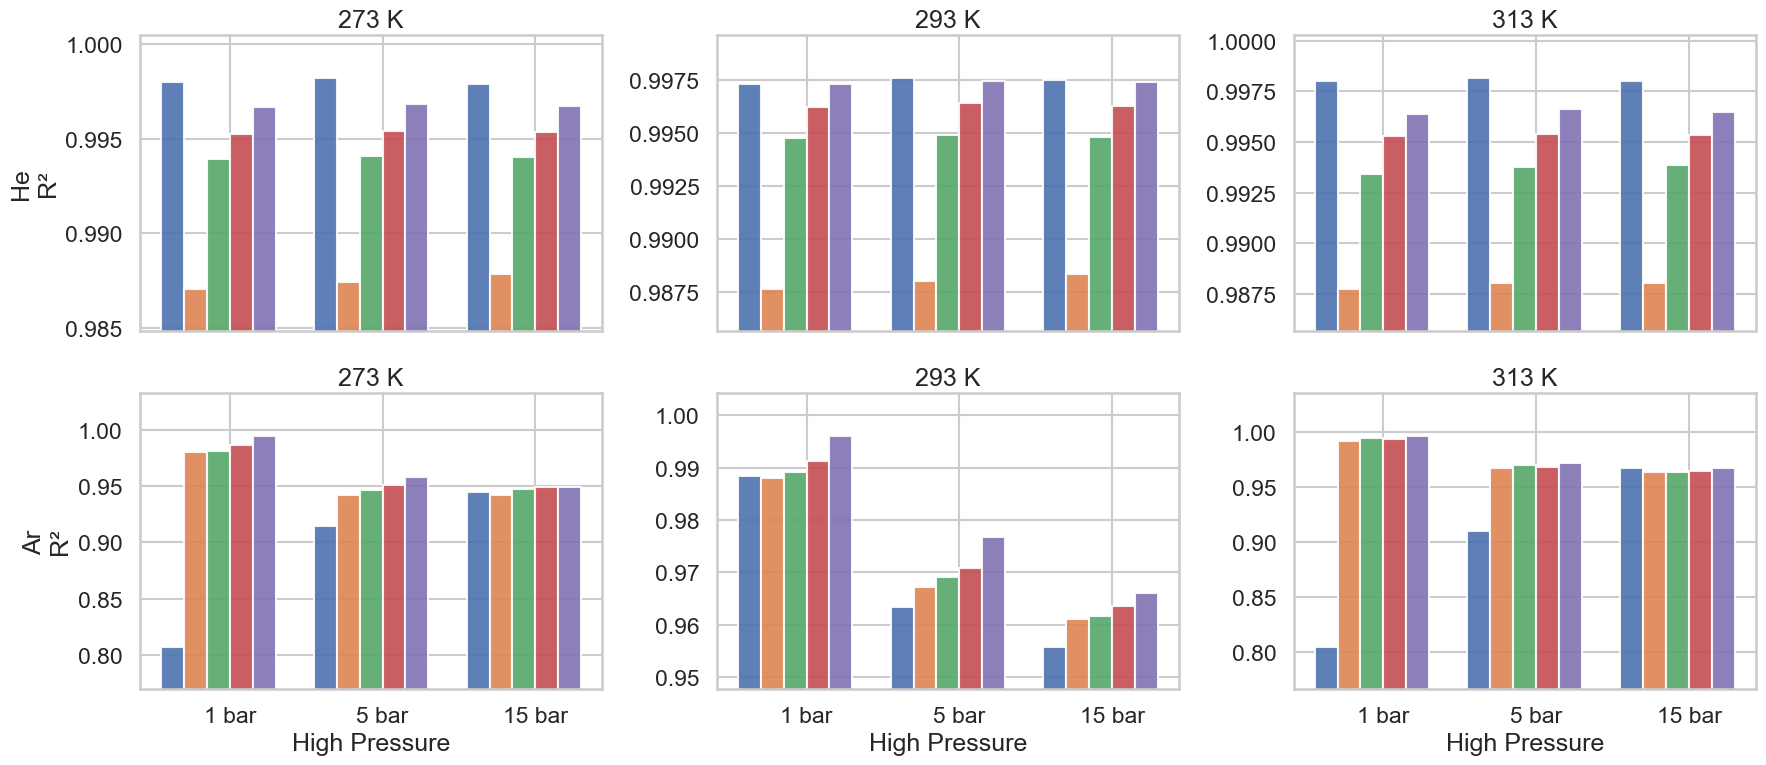

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="talk")

df = pd.read_csv("../Try13/METRICS_OUTPUT_pivot.csv")
df = df[(df["MODEL"]=="cat") & (df["SAMPLING"].str.contains("qt_then_rd"))].copy()

gases = ["He","Ar"]
temps = [273,293,313]
lows = ["Henry","0.01","0.05","0.1","0.5"]
highs = ["R2_MEAN_HIGH_1","R2_MEAN_HIGH_5","R2_MEAN_HIGH_15"]

fig, axes = plt.subplots(len(gases), len(temps), figsize=(18,8), sharey=False, sharex=True)

for i, gas in enumerate(gases):
    for j, temp in enumerate(temps):
        ax = axes[i,j] if len(gases)>1 else axes[j]
        subset = df[(df["GAS"]==gas) & (df["TEMP"]==temp)]
        if subset.empty:
            continue

        xpos = np.arange(len(highs))  # 1, 5, 15 bar
        width = 0.15
        all_vals = []  # 🔑 y축 범위 계산용 값 저장

        for k, low in enumerate(lows):
            sublow = subset[subset["LOW"]==low]
            if sublow.empty:
                continue
            vals = [sublow[h].mean() for h in highs]
            all_vals.extend(vals)
            ax.bar(xpos + k*width, vals, width, label=low, alpha=0.9)

        ax.set_xticks(xpos + width*len(lows)/2)
        ax.set_xticklabels([h.replace("R2_MEAN_HIGH_","")+" bar" for h in highs])

        # 🔑 자동 ylim 설정 (값 범위 기반 확대)
        if all_vals:
            vmin, vmax = min(all_vals), max(all_vals)
            margin = (vmax - vmin) * 0.2 if vmax > vmin else 0.01  # 여백
            ax.set_ylim(vmin - margin, vmax + margin)

        if i==len(gases)-1: ax.set_xlabel("High Pressure")
        if j==0: ax.set_ylabel(f"{gas}\nR²")
        ax.set_title(f"{temp} K")

# 범례는 figure 전체에서 한 번만
handles, labels = axes[0,0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()


In [17]:
vals

[0.9563451100414408, 0.9575112898410245, 0.965450295908273]

In [4]:
df.columns

Index(['GAS', 'TEMP', 'MODEL', 'SAMPLING', 'LOW', 'R2_MEAN_HIGH_1',
       'R2_MEAN_HIGH_5', 'R2_MEAN_HIGH_15', 'R2_STD_HIGH_1', 'R2_STD_HIGH_5',
       'R2_STD_HIGH_15', 'MAE_MEAN_HIGH_1', 'MAE_MEAN_HIGH_5',
       'MAE_MEAN_HIGH_15', 'MAE_STD_HIGH_1', 'MAE_STD_HIGH_5',
       'MAE_STD_HIGH_15', 'MAPE_MEAN_HIGH_1', 'MAPE_MEAN_HIGH_5',
       'MAPE_MEAN_HIGH_15', 'MAPE_STD_HIGH_1', 'MAPE_STD_HIGH_5',
       'MAPE_STD_HIGH_15', 'INPUT_HIGH_1', 'INPUT_HIGH_5', 'INPUT_HIGH_15'],
      dtype='object')

In [3]:
df

,GAS,TEMP,MODEL,SAMPLING,LOW,R2_MEAN_HIGH_1,R2_MEAN_HIGH_5,R2_MEAN_HIGH_15,R2_STD_HIGH_1,R2_STD_HIGH_5,...,MAE_STD_HIGH_15,MAPE_MEAN_HIGH_1,MAPE_MEAN_HIGH_5,MAPE_MEAN_HIGH_15,MAPE_STD_HIGH_1,MAPE_STD_HIGH_5,MAPE_STD_HIGH_15,INPUT_HIGH_1,INPUT_HIGH_5,INPUT_HIGH_15
0,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,0.980530,0.942551,0.942233,0.001539,0.002202,...,0.002964,3.604884,6.017872,6.906274,0.097235,0.173088,0.122752,struct+input,struct+input,struct+input
1,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.05,0.981844,0.946434,0.947935,0.000772,0.002550,...,0.005185,3.149899,5.811729,6.757988,0.097062,0.173467,0.146044,struct+input,struct+input,struct+input
2,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.10,0.986484,0.950708,0.948975,0.002860,0.002741,...,0.006056,2.959337,5.561020,6.672832,0.063514,0.145041,0.154566,struct+input,struct+input,struct+input
3,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.50,0.995210,0.958574,0.949225,0.000432,0.003612,...,0.006417,2.088218,5.123617,6.539972,0.029519,0.090167,0.121571,struct+input,struct+input,struct+input
36,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,0.987939,0.967201,0.961106,0.000889,0.001146,...,0.001825,3.163945,4.592780,5.698899,0.065706,0.046825,0.076660,struct+input,struct+input,struct+input
37,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.05,0.989225,0.969082,0.961640,0.002016,0.001683,...,0.004391,2.632042,4.262427,5.578408,0.087063,0.096453,0.193965,struct+input,struct+input,struct+input
38,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.10,0.991211,0.970808,0.963529,0.000325,0.001885,...,0.002416,2.534771,4.207946,5.577385,0.056771,0.049712,0.074902,struct+input,struct+input,struct+input
39,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.50,0.996107,0.976678,0.965971,0.000231,0.001637,...,0.004052,1.833201,3.736026,5.254246,0.033167,0.043637,0.126238,struct+input,struct+input,struct+input
72,Ar,313,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,0.991559,0.967340,0.963651,0.000244,0.004825,...,0.001245,2.904731,4.379958,5.360455,0.071018,0.134309,0.096533,struct+input,struct+input,struct+input
73,Ar,313,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.05,0.994393,0.969743,0.964138,0.000567,0.001802,...,0.002204,2.248791,4.067569,5.278337,0.024586,0.122536,0.071897,struct+input,struct+input,struct+input
